# Predicting the Correct Bill from the CRM: a Telecom Provisioning Case Study

**Case Study I · Sprint 3 final notebook** · Moodle section 8608

A 4-Play subscription (internet, TV, mobile and fixed line) is set up in several systems. The
**CRM** records what the customer bought; the **billing system** charges for it. Human and
automatic errors make the two drift apart. This notebook predicts the billing configuration a
customer *should* have from their CRM configuration, so that mismatches can be caught.

| | |
|---|---|
| Input | 745 yes/no CRM product flags per customer |
| Output | 731 yes/no billing items per customer |
| Metric | Exact Match Ratio (EMR): a customer counts only if all 731 items are right |
| **Final test EMR** | **97.51%** (95% CI 97.41–97.61), 94,681 of 97,100 customers exactly right |

### Results at a glance

| Model | Test EMR |
|---|---|
| Sprint 2 model | 95.04% |
| Sprint 3, Stage 1: corrupted training rows removed, model re-tuned | 97.21% |
| **Sprint 3, final: Stage 1 + long-tail specialists (Stage 2)** | **97.51%** |

Every test score was computed only after the model was frozen.

### Contents

1. [Setup](#setup)
2. [The data](#data)
3. [Validation strategy](#validation)
4. [Choosing the model (Sprint 2)](#modelling)
5. [A data audit (Sprint 3)](#audit)
6. [The final model, Stage 1](#stage1)
7. [Stage 2: specialists for the long-tail items](#stage2)
8. [Business use: catching provisioning errors](#business)
9. [Explainability: what did the model learn?](#shap)
10. [Final training and submission](#submission)
11. [Test results](#test)
12. [Conclusions](#conclusions)

Appendices: [A. Full experiment results](#appendix-a) · [B. Threats to validity](#appendix-b) · [C. Glossary](#appendix-c)

**About this notebook.** It is self-contained: all code is here, and it reads only the three
files provided by the professor (`train.csv`, `test.csv` and `solution.csv`). `solution.csv` is
read only in Chapter 11, after the model is frozen, and is never used to train or choose
anything. A full run takes about 25 minutes. The complete audit trail of every experiment is in
`docs/sprint3/SPRINT3_DIAGNOSTIC_LOG.md`.

<a id="setup"></a>
# 1. Setup

Libraries, the data folder, and one shared chart style.

In [1]:
import os
import re
import time
import warnings

os.environ.setdefault('OMP_NUM_THREADS', '6')
warnings.filterwarnings('ignore', message='X does not have valid feature names')

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from joblib import Parallel, delayed
from scipy import sparse
from scipy.stats import spearmanr
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.model_selection import GroupShuffleSplit, KFold

DATA = '../data'          # train.csv, test.csv, solution.csv (as provided by the professor)
OUT = f'{DATA}/derived'   # where the submission file is written
pd.set_option('display.max_colwidth', 90)
pd.set_option('display.width', 160)

# Chart style: one light surface, recessive axes, blue / orange series.
SURFACE, INK, INK2, GRID, AXIS = '#fcfcfb', '#0b0b0b', '#52514e', '#e1e0d9', '#c3c2b7'
BLUE, LIGHT_BLUE, ORANGE = '#2a78d6', '#9ec5f4', '#eb6834'
plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 9, 'figure.facecolor': SURFACE})


def style(ax, grid='x'):
    ax.set_facecolor(SURFACE)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color(AXIS)
    ax.tick_params(colors=INK2, labelsize=8)
    ax.grid(axis=grid, color=GRID, linewidth=0.6)
    ax.set_axisbelow(True)

<a id="data"></a>
# 2. The data

Every CRM and billing column is a 0/1 flag, so the files are read with a compact `uint8` type
instead of pandas' default `int64`, which would use eight times the memory.

In [2]:
t0 = time.time()
header = pd.read_csv(f'{DATA}/train.csv', nrows=0).columns.tolist()
crm_cols = [c for c in header if c.startswith('CRM')]
bil_cols = [c for c in header if c.startswith('BIL')]
dtypes = {c: 'uint8' for c in crm_cols + bil_cols} | {'MSISDN': str}

train = pd.read_csv(f'{DATA}/train.csv', dtype=dtypes)
test = pd.read_csv(f'{DATA}/test.csv', dtype={k: v for k, v in dtypes.items() if k in set(crm_cols) | {'MSISDN'}})
X = train[crm_cols].to_numpy(np.uint8)
Y_raw = train[bil_cols].to_numpy(np.uint8)
X_test = test[crm_cols].to_numpy(np.uint8)
msisdn_test = test['MSISDN'].to_numpy()
del train

print(f'train: {X.shape[0]:,} rows x {X.shape[1]} CRM + {Y_raw.shape[1]} BIL columns | '
      f'test: {X_test.shape[0]:,} rows | loaded in {time.time() - t0:.0f}s')
print(f'all values binary: {max(X.max(), Y_raw.max(), X_test.max()) <= 1}')

train: 187,442 rows x 745 CRM + 731 BIL columns | test: 97,100 rows | loaded in 11s
all values binary: True


### How sparse is the billing side?

In [3]:
pack_crm = np.array([c.endswith('_PACK') for c in crm_cols])
pack_bil = np.array([c.endswith('_PACK') for c in bil_cols])
print(f'CRM: {pack_crm.sum()} pack flags + {(~pack_crm).sum()} categorical one-hot columns')
print(f'BIL: {pack_bil.sum()} pack flags + {(~pack_bil).sum()} categorical one-hot columns')
print(f'active columns per customer: CRM {X.sum(1).mean():.1f}, BIL {Y_raw.sum(1).mean():.1f}')

prev = Y_raw.mean(0)
tiers = pd.cut(prev, [-1e-9, 0.001, 0.01, 0.1, 0.5, 1.0],
               labels=['< 0.1%', '0.1–1%', '1–10%', '10–50%', '≥ 50%'])
print('\nBIL columns by prevalence (share of customers who have the item):')
display(pd.Series(tiers).value_counts().sort_index().rename('BIL columns').to_frame().T)

CRM: 730 pack flags + 15 categorical one-hot columns
BIL: 717 pack flags + 14 categorical one-hot columns


active columns per customer: CRM 15.3, BIL 14.7

BIL columns by prevalence (share of customers who have the item):


,< 0.1%,0.1–1%,1–10%,10–50%,≥ 50%
BIL columns,10,607,82,23,9


A typical customer has about 15 of the 731 billing items, and more than 600 billing items
appear in fewer than 1% of customers. Getting *every* item right is hard, because most items
are rare.

### Duplicates, noise, and how new the test customers are

In [4]:
def row_keys(A):
    # Exact identity of each 0/1 row as bytes (np.packbits): no hashing, no collisions.
    return [r.tobytes() for r in np.packbits(np.asarray(A, dtype=np.uint8), axis=1)]


def factorize_rows(A):
    codes, uniq = pd.factorize(pd.Series(row_keys(A)), sort=False)
    return codes.astype(np.int64), len(uniq)


groups, n_crm_cfg = factorize_rows(X)
bil_codes, n_bil_cfg = factorize_rows(Y_raw)
pairs = pd.DataFrame({'crm': groups, 'bil': bil_codes})
n_bil_per_crm = pairs.groupby('crm')['bil'].nunique()
train_keys = set(row_keys(X))
seen = sum(k in train_keys for k in row_keys(X_test))

print(f'distinct CRM configurations: {n_crm_cfg:,} | distinct BIL configurations: {n_bil_cfg:,}')
print(f'CRM configurations with more than one BIL configuration (provisioning errors): '
      f'{(n_bil_per_crm > 1).sum():,} ({(n_bil_per_crm > 1).mean():.2%})')
print(f'test rows whose CRM configuration appears in train: {seen} of {len(X_test):,} ({seen / len(X_test):.4%})')

distinct CRM configurations: 67,434 | distinct BIL configurations: 67,201
CRM configurations with more than one BIL configuration (provisioning errors): 617 (0.91%)
test rows whose CRM configuration appears in train: 6 of 97,100 (0.0062%)


Three facts from this cell shaped the whole project:
- **The training labels contain noise.** In about 1% of CRM configurations, customers with
  identical CRM records have different bills. These are the provisioning errors the brief
  warns about.
- **Test customers are new.** Only 6 of 97,100 test customers have a CRM configuration that
  appears in training. A lookup table cannot work: the model has to generalise.
- **The mapping is many-to-one.** Different CRM configurations can lead to the same bill.

### Is there a compact structure in the CRM data?

In Sprint 1 the CRM columns were compressed with SVD, a method similar to PCA. This check shows
why that did not pay off:

In [5]:
# Recomputed here from train.csv (Sprint 1 Section 11 used the same truncated SVD on the CRM columns).
t0 = time.time()
svd = TruncatedSVD(n_components=80, algorithm='randomized', random_state=42).fit(sparse.csr_matrix(X, dtype=np.float32))
cum = np.cumsum(svd.explained_variance_ratio_)
k80 = int(np.argmax(cum >= 0.80)) + 1 if cum[-1] >= 0.80 else '> 80'
print(f'truncated SVD of the CRM columns: {k80} components needed for 80% of the variance '
      f'(first component alone: {svd.explained_variance_ratio_[0]:.1%}) -> no low-dimensional structure '
      f'[{time.time() - t0:.0f}s]')

truncated SVD of the CRM columns: 45 components needed for 80% of the variance (first component alone: 4.8%) -> no low-dimensional structure [3s]


It takes 45 components to explain 80% of the variance, and the first one explains less than
5%. The CRM data has no compact structure, so the final model works on the raw flags.

<a id="validation"></a>
# 3. Validation strategy

Because the test customers are new, validation must also use customers the model has never
seen.
- **Grouped split.** Customers with an identical CRM configuration always stay on the same side
  of the split (20% validation). The main split uses seed 42, and every decision is repeated on
  a second split (seed 7).
- **Consensus targets.** When a CRM configuration appears several times, validation scores
  against its most frequent bill. This way the model is not rewarded for copying provisioning
  errors.

In [6]:
def consensus_targets(crm_codes, Y):
    # Modal full BIL configuration per CRM configuration (ties: first seen).
    codes, _ = factorize_rows(Y)
    p = pd.DataFrame({'crm': crm_codes, 'bil': codes, 'pos': np.arange(len(Y))})
    cnt = p.groupby(['crm', 'bil'], sort=False).agg(n=('pos', 'size'), first=('pos', 'min')).reset_index()
    modal = cnt.sort_values(['crm', 'n', 'first'], ascending=[True, False, True]).drop_duplicates('crm')
    src = modal.set_index('crm')['first'].reindex(crm_codes).to_numpy()
    return Y[src], codes != codes[src]


def grouped_holdout(groups, seed=42):
    return next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
                .split(np.zeros(len(groups)), groups=groups))


Y, noisy = consensus_targets(groups, Y_raw)
tr, va = grouped_holdout(groups)
print(f'training rows that differ from their configuration consensus: {noisy.sum():,} ({noisy.mean():.2%})')
print(f'train fold {len(tr):,} rows | validation fold {len(va):,} rows | configurations on both sides: '
      f'{len(set(groups[tr]) & set(groups[va]))}')

training rows that differ from their configuration consensus: 1,315 (0.70%)
train fold 151,057 rows | validation fold 36,385 rows | configurations on both sides: 0


About 0.7% of training rows differ from their configuration's consensus bill, and no
configuration appears on both sides of the split.

<a id="modelling"></a>
# 4. Choosing the model (Sprint 2)

Sprint 2 compared the four modelling families suggested in the brief on the same split. Those
runs took hours, so their results are reported here rather than recomputed (full tables in
[Appendix A](#appendix-a)). The chosen model is re-fitted live in Chapter 6.

| Approach | Validation EMR (all rows) |
|---|---|
| Label powerset: pick a billing configuration seen in training | 23.1% |
| k-nearest neighbours: copy the bill of similar customers | 52.0% |
| Classifier chain | 80.6% |
| **One LightGBM per billing item, regularised** | **87.8%** |

What Sprint 2 taught us:
- **Billing is close to "one product, its billing items".** Two customers who differ by one CRM
  product usually differ by one billing item. One model per billing item learns this well.
  Copying neighbours and choosing among known bills both fail, because new CRM configurations
  produce new bills.
- **The raw columns beat Sprint 1's engineered features.** On identical training rows,
  collapsing correlated columns cost about 6 points and the SVD components about 33.
- **Regularisation mattered most.** The regularised model reached 87.8% on validation and
  95.0% on test.

That gap between validation and test was the starting point of Sprint 3.

<a id="audit"></a>
# 5. A data audit (Sprint 3)

Why was validation seven points worse than test? Following the professor's hints (PCA, one-hot
encoding, hidden pre-processing problems), we audited every family of columns. Two findings
explain the gap.

### Finding 1: impossible categories exist only in training

Business line, subscriber type and subscriber status are one-hot blocks, so each customer
should have exactly one value in each. We call a row **test-like** when every block has exactly
one value and never the placeholder value `0`.

In [7]:
def test_like_mask(A):
    blocks = {}
    for i, c in enumerate(crm_cols):
        m = re.match(r'^CRM_(.+?)_ORIG_(.+)$', c)
        if m:
            blocks.setdefault(m.group(1), []).append((i, m.group(2)))
    ok = np.ones(len(A), bool)
    for items in blocks.values():
        ok &= A[:, [i for i, _ in items]].sum(1) == 1
        zero = [i for i, v in items if v == '0']
        if zero:
            ok &= A[:, zero].sum(1) == 0
    return ok


test_like = test_like_mask(X)
print(f'test-like rows: train {test_like.mean():.2%} | test {test_like_mask(X_test).mean():.4%}')

status = np.array([c.startswith('CRM_SUBSCRIBER_STATUS_ORIG_') for c in crm_cols])
names = np.array([c.split('_ORIG_')[1] for c in np.array(crm_cols)[status]])
multi = X[:, status].sum(1) >= 2
combos = pd.Series(['+'.join(names[X[i, status] == 1]) for i in np.flatnonzero(multi)]).value_counts()
print(f'\n{multi.sum():,} training customers have 2+ statuses at once; most common combinations:')
display(combos.head(8).rename('customers').to_frame().T)

test-like rows: train 98.48% | test 99.9990%

1,901 training customers have 2+ statuses at once; most common combinations:


,Active+Barring,Active+Block_1_Way,Active+Block_2_Way,Active+Pre_Deactivated,Active+Deactive,0+Active,Active+Suspend,Active+Idle
customers,142,141,136,129,129,127,127,121


Every test customer is test-like, but 1.5% of training customers are not. Some are `Active`
and `Barring` at the same time. `Active` is paired with every other status at about the same
rate, although those statuses differ in natural frequency by up to 100 times. A real status
history would not look like this. It looks like values **injected at random**.

### Finding 2: bursts of random rare products

We call a CRM product **rare** when fewer than 0.2% of training customers have it.

471 rare CRM packs | rows with >= 3 of them: train 8.00%, test 0.55%
in those rows the 471 rare packs are used almost equally often: coefficient of variation 0.12; rank correlation with their natural frequency in test 0.23
rare packs per row — not test-like rows: 6.43 CRM / 6.27 BIL; test-like rows: 0.50 / 0.50

rare CRM packs (rows) vs rare BIL items (columns) per training row — the counts move together:


rare BIL items,0,1,2,3,4,5,6
rare CRM packs,,,,,,,
0,159907,592,252,77,52,26,33
1,847,6020,485,235,161,102,137
2,143,329,1968,318,293,175,294
3,117,235,411,588,342,260,526
4,62,156,289,401,405,311,739
5,32,116,180,251,329,326,856
6,33,146,359,558,733,941,5294


a rare CRM pack's most associated rare BIL item appears with it in 29% of clean rows (median), but only 5% of rows with 3+ rare packs


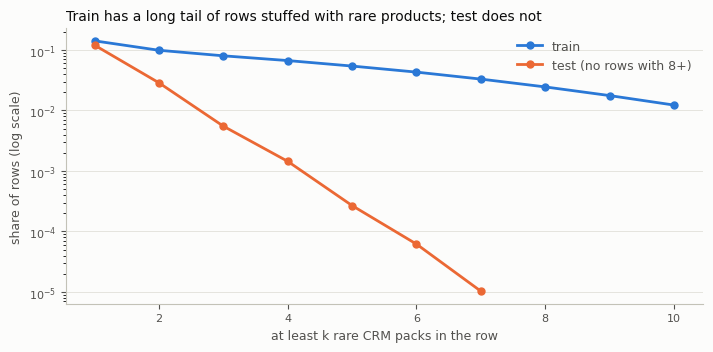

In [8]:
RARE_FREQ = 0.002
rare_crm = pack_crm & (X.mean(0) < RARE_FREQ)
rare_bil = pack_bil & (Y.mean(0) < RARE_FREQ)
rare_tr, rare_te = X[:, rare_crm].sum(1), X_test[:, rare_crm].sum(1)
rare_bil_tr = Y[:, rare_bil].sum(1)
print(f'{rare_crm.sum()} rare CRM packs | rows with >= 3 of them: train {np.mean(rare_tr >= 3):.2%}, '
      f'test {np.mean(rare_te >= 3):.2%}')

heavy = rare_tr >= 3
use = X[heavy][:, rare_crm].sum(0)
print(f'in those rows the {rare_crm.sum()} rare packs are used almost equally often: '
      f'coefficient of variation {use.std() / use.mean():.2f}; '
      f'rank correlation with their natural frequency in test {spearmanr(use, X_test[:, rare_crm].mean(0)).statistic:.2f}')
print(f'rare packs per row — not test-like rows: {rare_tr[~test_like].mean():.2f} CRM / '
      f'{rare_bil_tr[~test_like].mean():.2f} BIL; test-like rows: {rare_tr[test_like].mean():.2f} / '
      f'{rare_bil_tr[test_like].mean():.2f}')

print('\nrare CRM packs (rows) vs rare BIL items (columns) per training row — the counts move together:')
display(pd.crosstab(pd.Series(np.minimum(rare_tr, 6), name='rare CRM packs'),
                    pd.Series(np.minimum(rare_bil_tr, 6), name='rare BIL items')))


def partner_rate(mask):
    # For each rare CRM pack: how often its most associated rare BIL item appears with it.
    Xs, Ys = X[mask][:, rare_crm].astype(np.float32), Y[mask][:, rare_bil].astype(np.float32)
    n = Xs.sum(0)
    rate = (Xs.T @ Ys).max(1) / np.maximum(n, 1)
    return np.median(rate[n >= 5])


clean_rows = test_like & (rare_tr < 3)
print(f'a rare CRM pack\'s most associated rare BIL item appears with it in {partner_rate(clean_rows):.0%} of clean rows '
      f'(median), but only {partner_rate(rare_tr >= 3):.0%} of rows with 3+ rare packs')

ks = np.arange(1, 11)
share_te = np.array([np.mean(rare_te >= k) for k in ks])
fig, ax = plt.subplots(figsize=(7.2, 3.6))
ax.plot(ks, [np.mean(rare_tr >= k) for k in ks], color=BLUE, lw=2, marker='o', ms=5, label='train')
ax.plot(ks[share_te > 0], share_te[share_te > 0], color=ORANGE, lw=2, marker='o', ms=5,
        label=f'test (no rows with {ks[share_te > 0].max() + 1}+)')
ax.set_yscale('log')
style(ax, grid='y')
ax.set_xlabel('at least k rare CRM packs in the row', color=INK2)
ax.set_ylabel('share of rows (log scale)', color=INK2)
ax.set_title('Train has a long tail of rows stuffed with rare products; test does not', loc='left', color=INK, fontsize=10)
ax.legend(frameon=False, labelcolor=INK2)
plt.tight_layout()
plt.show()

Three signs point to random injection. They are strong circumstantial evidence, not proof, so
we call these rows *suspected* corrupted.
1. **Training has a long tail that test does not.** 8% of training customers have three or more
   rare products, against 0.55% of test customers (chart).
2. **The rare products are used almost uniformly.** Real customers do not choose products at
   random.
3. **Both sides are corrupted together, but with unrelated identities.** The numbers of rare
   CRM products and rare billing items rise together (table), but the usual pairing between a
   product and its billing item appears six times less often in these rows.

The impossible categories arrive with the same bursts, so we treat them as one corruption.
These rows make validation look worse than test, and they teach the model false product links.

### The fix

- **Remove suspected-corrupted rows from training.** These are rows that are not test-like or
  carry four or more rare products, about 7% of training. They are removed from training only:
  every test customer is still scored. The cut-off was chosen with a sweep on two splits
  ([Appendix A](#appendix-a)).
- **Measure on clean-like rows.** These are test-like validation rows with fewer than three
  rare products. The definition uses CRM inputs only, and this score tracks the test score.
- **Re-tune on the clean data.** Smaller leaves now help (`min_child_samples` 5 instead of 20).
  L2 regularisation must stay on: without it, one rare billing item fires for 27% of customers.

Several other ideas were tested on both splits and rejected: other cleaning methods, repairing
rows instead of dropping them, more model capacity, extra count features, a lower threshold for
rare items, and the Sprint 1 rules ([Appendix A](#appendix-a)).

<a id="stage1"></a>
# 6. The final model, Stage 1

One LightGBM classifier per billing item, on the 745 raw CRM flags:
- trained on unique CRM configurations with their consensus bill, after removing the
  suspected-corrupted rows;
- 100 trees, 15 leaves, `min_child_samples=5`, `reg_lambda=1`, decision threshold 0.5.

Here it is fitted on the seed-42 training fold, so that we can score and examine it.

In [9]:
PARAMS = dict(n_estimators=100, num_leaves=15, learning_rate=0.1, min_child_samples=5,
              reg_lambda=1.0, verbose=-1)


def fit_one(Xf, y):
    if y.min() == y.max():
        return float(y[0])
    return lgb.LGBMClassifier(n_jobs=2, **PARAMS).fit(Xf, y)


def fit_models(Xu, Yu):
    Xf = Xu.astype(np.float32)
    return Parallel(n_jobs=8, backend='threading')(delayed(fit_one)(Xf, Yu[:, j]) for j in range(Yu.shape[1]))


def predict_proba(models, A):
    Af = A.astype(np.float32)
    one = lambda m: np.full(len(Af), m, np.float32) if isinstance(m, float) else m.predict_proba(Af)[:, 1]
    return np.column_stack(Parallel(n_jobs=8, backend='threading')(delayed(one)(m) for m in models))


def unique_configs(A, B):
    codes, _ = factorize_rows(A)
    _, first = np.unique(codes, return_index=True)
    return A[first], B[first]


def predict(models, A):
    P = predict_proba(models, A)
    return P, (P >= 0.5).astype(np.uint8)


keep = tr[test_like[tr] & (rare_tr[tr] < 4)]
Xu, Yu = unique_configs(X[keep], Y[keep])
t0 = time.time()
models = fit_models(Xu, Yu)
P_val, pred_val = predict(models, X[va])
print(f'dropped {len(tr) - len(keep):,} suspected-corrupted training rows; '
      f'fitted 731 models on {len(Xu):,} unique configurations in {time.time() - t0:.0f}s')

dropped 10,476 suspected-corrupted training rows; fitted 731 models on 43,552 unique configurations in 170s


### Validation score

In [10]:
Yv = Y[va]
clean_like = test_like & (rare_tr < 3)
for name, m in [('all validation rows', np.ones(len(va), bool)), ('test-like rows', test_like[va]),
                ('clean-like rows (primary)', clean_like[va])]:
    emr = (pred_val[m] == Yv[m]).all(1).mean()
    print(f'{name:28s} {m.sum():6,} rows   EMR {emr:.2%}')

cl = clean_like[va]
yt, yp = Yv[cl], pred_val[cl]
active = yt.sum(0) > 0
report = pd.Series({
    'EMR': (yt == yp).all(1).mean(),
    'bit accuracy': (yt == yp).mean(),
    'F1 micro': f1_score(yt, yp, average='micro'),
    'F1 macro (columns with positives)': f1_score(yt[:, active], yp[:, active], average='macro', zero_division=0),
    'precision micro': precision_score(yt, yp, average='micro'),
    'recall micro': recall_score(yt, yp, average='micro'),
})
display(report.to_frame('clean-like validation').style.format('{:.4f}'))
cm = pd.DataFrame([[int(((yt == 1) & (yp == 1)).sum()), int(((yt == 1) & (yp == 0)).sum())],
                   [int(((yt == 0) & (yp == 1)).sum()), int(((yt == 0) & (yp == 0)).sum())]],
                  index=['actual 1', 'actual 0'], columns=['predicted 1', 'predicted 0'])
display(cm.style.format('{:,}'))
err = (yt != yp).sum(1)
r = rare_tr[va][cl]
print(f'EMR on clean-like rows with no rare pack: {np.mean(err[r == 0] == 0):.2%} | '
      f'with 1–2 rare packs ({np.mean(r > 0):.1%} of rows): {np.mean(err[r > 0] == 0):.2%}')

all validation rows          36,385 rows   EMR 88.64%
test-like rows               35,818 rows   EMR 90.04%
clean-like rows (primary)    33,261 rows   EMR 96.79%


,clean-like validation
EMR,0.9679
bit accuracy,0.9998
F1 micro,0.9959
F1 macro (columns with positives),0.5348
precision micro,0.9989
recall micro,0.9929


,predicted 1,predicted 0
actual 1,"474,408","3,378"
actual 0,525,"23,835,480"


EMR on clean-like rows with no rare pack: 99.17% | with 1–2 rare packs (7.1% of rows): 65.50%


On clean-like validation rows, **96.79%** of customers are exactly right. Customers without a
rare product are 99.2% exact, and almost all remaining errors sit in the 7% of customers with
one or two rare products. Most errors are **missed** billing items: 3,378 false negatives
against 525 false positives.

### Why exact match is harsh, and why errors cluster

With 731 items per customer, even a tiny error rate per item would sink EMR if the errors were
spread evenly.

In [11]:
bit_err = (yt != yp).mean()
print(f'bit error rate {bit_err:.2e} -> {bit_err * 731:.3f} wrong bits per customer on average')
print(f'EMR if errors were independent across bits: (1 - e)^731 = {(1 - bit_err) ** 731:.2%} | actual EMR {np.mean(err == 0):.2%}')
print(f'{np.mean(err >= 2):.2%} of customers carry {err[err >= 2].sum() / err.sum():.0%} of all wrong bits')

bit error rate 1.61e-04 -> 0.117 wrong bits per customer on average
EMR if errors were independent across bits: (1 - e)^731 = 88.93% | actual EMR 96.79%
2.15% of customers carry 91% of all wrong bits


If errors were independent, EMR would be 88.9%. It is 96.8% because errors cluster: 2% of
customers carry 91% of the wrong items. Improving EMR is about *which customers* fail, not
about accuracy per item.

### How certain is the validation score?

Customers with the same CRM configuration share both the prediction and the target, so they
are not independent. We therefore resample whole configurations, not rows.

In [12]:
def config_bootstrap(groups_, values, b=2000, seed=0):
    codes, _ = pd.factorize(groups_)
    s, n = np.bincount(codes, weights=values), np.bincount(codes)
    idx = np.random.default_rng(seed).integers(0, len(s), size=(b, len(s)))
    boot = s[idx].sum(1) / n[idx].sum(1)
    return s.sum() / n.sum(), boot.std(), np.percentile(boot, [2.5, 97.5])


ok_row = (err == 0).astype(float)
m, se, (lo, hi) = config_bootstrap(groups[va][cl], ok_row)
print(f'clean-like validation EMR {m:.2%} | configuration-level SE {se * 100:.2f} pt '
      f'(a naive row-level SE would say {np.sqrt(m * (1 - m) / len(ok_row)) * 100:.2f}) | 95% CI [{lo:.2%}, {hi:.2%}]')

clean-like validation EMR 96.79% | configuration-level SE 0.38 pt (a naive row-level SE would say 0.10) | 95% CI [95.99%, 97.48%]


The interval is wide (about ±0.7 points) because a few very common configurations weigh
heavily. That is why every modelling choice was made with **paired tests**, where both models
are scored on the same resampled customers, on two splits, and confirmed with 5-fold
cross-validation (96.83% ± 0.20). The test set, where every customer is its own configuration,
gives the precise final number.

A tuned logistic regression reaches 96.56% and 96.15% on the two splits, so LightGBM's edge is
real but small ([Appendix A](#appendix-a)).

### Which customers fail?

In [13]:
crm_arr = np.array(crm_cols)
Xcl = X[va][cl]
seg_rows = []


def segment(name, labels):
    for lab in pd.unique(labels):
        mm = labels == lab
        seg_rows.append({'segment': name, 'value': lab, 'customers': int(mm.sum()), 'EMR': np.mean(err[mm] == 0),
                         'share of wrong customers': (err[mm] > 0).sum() / max((err > 0).sum(), 1)})


for g in ('SUBSCRIBER_STATUS', 'SUBSCRIBER_TYPE'):
    cols = [i for i, c in enumerate(crm_cols) if c.startswith(f'CRM_{g}_ORIG_')]
    segment(g.lower(), np.array([c.split('_ORIG_')[1] for c in crm_arr[cols]])[Xcl[:, cols].argmax(1)])
segment('CRM products per customer', pd.cut(Xcl[:, pack_crm].sum(1), [0, 10, 15, 20, 1000],
                                             labels=['<= 10', '11-15', '16-20', '21+']).astype(str))
segment('rare CRM products', np.where(rare_tr[va][cl] > 0, '1-2', '0'))
seg = pd.DataFrame(seg_rows).sort_values(['segment', 'customers'], ascending=[True, False]).set_index(['segment', 'value'])
display(seg.style.format({'EMR': '{:.2%}', 'share of wrong customers': '{:.1%}', 'customers': '{:,}'}))

Product mix matters, not status or contract type. Customers with one or two rare products (7%
of rows) account for three quarters of the wrong customers, and EMR also drops for very large
baskets of 16 or more products.

### Items the model cannot vouch for

In [14]:
tp_c = ((yt == 1) & (yp == 1)).sum(0)
fp_c = ((yt == 0) & (yp == 1)).sum(0)
fn_c = ((yt == 1) & (yp == 0)).sum(0)
f1_c = np.where(tp_c + fp_c + fn_c > 0, 2 * tp_c / np.maximum(2 * tp_c + fp_c + fn_c, 1), np.nan)
weak = f1_c < 0.5
has_weak = yt[:, weak].any(1)
print(f'billing items with validation F1 < 0.5: {np.nansum(weak)} of 731 columns, but only '
      f'{yt[:, weak].sum() / yt.sum():.2%} of all billed items')
print(f'customers billed for at least one such item: {has_weak.mean():.2%} | their EMR {np.mean(err[has_weak] == 0):.1%} '
      f'vs {np.mean(err[~has_weak] == 0):.2%} for everyone else')

billing items with validation F1 < 0.5: 314 of 731 columns, but only 0.34% of all billed items
customers billed for at least one such item: 2.38% | their EMR 5.8% vs 99.01% for everyone else


314 billing items have a validation F1 below 0.5. Together they are only 0.34% of everything
billed, but 2.4% of customers have at least one of them, and those customers are almost never
exactly right. This is also why **macro F1**, which weights every item equally, is only about
0.53 while micro F1 is 0.996. The next chapter tries to recover part of this long tail.

<a id="stage2"></a>
# 7. Stage 2: specialists for the long-tail items

About 330 billing items are almost never predicted. Before adding any model, we checked
whether they carry a learnable signal, using the training data only:

| Group of long-tail items | Items | Mean F1 with Stage 1 |
|---|---|---|
| Billed for one CRM product | 14 | 0.41 |
| Billed for a combination of 2–3 CRM products | 105 | 0.25 |
| No CRM signal; positives sit next to injected rare products | 212 | 0.01 |

The first two groups follow real CRM patterns that carry over to new customers: on validation
those patterns are right 92–93% of the time. Stage 1 under-uses them because each item has only
20 to 50 training examples. The third group looks like what is left of the random injection.
Over 90% of all long-tail positives sit on customers with at least one rare product.

**The design**
1. **Long-tail items** are the items whose out-of-fold F1 inside the training data is below
   0.5. Only training labels are used to pick them.
2. **Specialists**: one extra LightGBM per long-tail item, with the same settings as Stage 1
   but with the rare positive examples up-weighted.
3. **Add-only, and only where it is plausible.** A specialist may switch an item *on* when
   Stage 1 said no, and only for customers with at least one rare product. It never removes
   anything Stage 1 predicted.

We also tried tuned thresholds, communities of co-occurring billing items, stacked Stage-1
probabilities, mined CRM rules and a targeted classifier chain. None did better, and several
hurt EMR ([Appendix A](#appendix-a)). The rare-product condition was chosen after looking at
errors on the first split, so the second split and the 5-fold results below are the real
evidence.

In [15]:
def config_weights(A):
    # Rows per unique configuration, in the order returned by unique_configs.
    codes, _ = factorize_rows(A)
    _, first = np.unique(codes, return_index=True)
    return np.bincount(codes)[codes[first]].astype(np.float32)


def oof_proba(Xu_, Yu_, n_splits=5):
    # Out-of-fold Stage-1 probabilities on the training configurations (each fold = whole configurations).
    oof = np.zeros(Yu_.shape, np.float32)
    for a, b in KFold(n_splits, shuffle=True, random_state=0).split(Xu_):
        oof[b] = predict_proba(fit_models(Xu_[a], Yu_[a]), Xu_[b])
    return oof


def long_tail_labels(Yu_, oof, w):
    # Items whose row-weighted out-of-fold F1 at 0.5 is below 0.5.
    Yb, Pb = Yu_.astype(bool), oof >= 0.5
    tp, fp, fn = w @ (Yb & Pb), w @ (~Yb & Pb), w @ (Yb & ~Pb)
    f1 = np.where(tp + fp + fn > 0, 2 * tp / np.maximum(2 * tp + fp + fn, 1e-9), 1.0)
    return np.flatnonzero((Yu_.sum(0) > 0) & (f1 < 0.5))


def fit_specialists(Xu_, Yu_, labels):
    Xf = Xu_.astype(np.float32)

    def one(j):
        y = Yu_[:, j]
        spw = float(np.clip(np.sqrt((len(y) - y.sum()) / max(y.sum(), 1)), 1, 10))
        return lgb.LGBMClassifier(n_jobs=2, scale_pos_weight=spw, **PARAMS).fit(Xf, y)
    return Parallel(n_jobs=8, backend='threading')(delayed(one)(j) for j in labels)


def two_stage(pred1, specialists, labels, A):
    P2 = predict_proba(specialists, A)
    gate = (A[:, rare_crm].sum(1) > 0)[:, None]           # customers with >= 1 rare CRM product
    out = pred1.copy()
    sub_ = out[:, labels]
    out[:, labels] = np.where((sub_ == 0) & (P2 >= 0.5) & gate, 1, sub_)   # add-only
    return out


t0 = time.time()
lt_val = long_tail_labels(Yu, oof_proba(Xu, Yu), config_weights(X[keep]))
spec_val = fit_specialists(Xu, Yu, lt_val)
pred_val2 = two_stage(pred_val, spec_val, lt_val, X[va])
print(f'{len(lt_val)} long-tail items (training OOF F1 < 0.5); 5 out-of-fold fits + {len(lt_val)} specialists '
      f'in {time.time() - t0:.0f}s')

332 long-tail items (training OOF F1 < 0.5); 5 out-of-fold fits + 332 specialists in 1123s


### Does it help?

In [16]:
yp2 = pred_val2[cl]
ok1, ok2 = (yp == yt).all(1), (yp2 == yt).all(1)
r_cl = rare_tr[va][cl]


def item_masks(Pr):
    Yb, Pb = yt.astype(bool), Pr.astype(bool)
    return (Yb & Pb), (~Yb & Pb), (Yb & ~Pb)


def macro(tp, fp, fn):
    act = (tp + fn) > 0
    return np.where(act, 2 * tp / np.maximum(2 * tp + fp + fn, 1e-9), 0).sum(-1) / act.sum(-1)


def summary(Pr, ok):
    tp, fp, fn = [m_.sum(0).astype(float) for m_ in item_masks(Pr)]
    return {'clean-like EMR': f'{ok.mean():.2%}', 'macro F1': f'{macro(tp, fp, fn):.4f}',
            'micro F1': f'{2 * tp.sum() / (2 * tp.sum() + fp.sum() + fn.sum()):.4f}',
            'wrong bits: false positives': f'{int(fp.sum()):,}', 'wrong bits: false negatives': f'{int(fn.sum()):,}',
            'items with positives never predicted': int(((tp + fn > 0) & (tp == 0)).sum()),
            'EMR, customers without a rare product': f'{ok[r_cl == 0].mean():.2%}',
            'EMR, customers with 1-2 rare products': f'{ok[r_cl > 0].mean():.2%}'}


display(pd.DataFrame({'Stage 1': summary(yp, ok1), 'Stage 1 + Stage 2': summary(yp2, ok2)}))

# Paired bootstrap over configurations (both models scored on the same resampled rows).
codes_v, _ = pd.factorize(groups[va][cl])
n_cfg = codes_v.max() + 1
Gm = sparse.csr_matrix((np.ones(len(codes_v), np.float32), (codes_v, np.arange(len(codes_v)))), shape=(n_cfg, len(codes_v)))
rng_b = np.random.default_rng(0)
Wb = np.stack([np.bincount(rng_b.integers(0, n_cfg, n_cfg), minlength=n_cfg) for _ in range(1000)]).astype(np.float32)
n_rows_cfg = np.asarray(Gm.sum(1)).ravel()


def boot(Pr, ok):
    tp, fp, fn = [Wb @ (Gm @ m_.astype(np.float32)) for m_ in item_masks(Pr)]
    return macro(tp, fp, fn), (Wb @ (Gm @ ok.astype(np.float32))) / (Wb @ n_rows_cfg)


(f1a, ea), (f1b, eb) = boot(yp, ok1), boot(yp2, ok2)
lo_f, hi_f = np.percentile(f1b - f1a, [2.5, 97.5])
lo_e, hi_e = np.percentile((eb - ea) * 100, [2.5, 97.5])
d_f1 = macro(*[m_.sum(0).astype(float) for m_ in item_masks(yp2)]) - macro(*[m_.sum(0).astype(float) for m_ in item_masks(yp)])
print(f'Stage 2 vs Stage 1 (paired, resampling configurations): macro F1 {d_f1:+.4f} [{lo_f:+.4f}, {hi_f:+.4f}] | '
      f'EMR {(ok2.mean() - ok1.mean()) * 100:+.2f} pt [{lo_e:+.2f}, {hi_e:+.2f}] | '
      f'customers recovered {int((ok2 & ~ok1).sum())}, broken {int((ok1 & ~ok2).sum())}')

,Stage 1,Stage 1 + Stage 2
clean-like EMR,96.79%,96.92%
macro F1,0.5348,0.5483
micro F1,0.9959,0.9958
wrong bits: false positives,525,715
wrong bits: false negatives,"3,378","3,319"
items with positives never predicted,272,247
"EMR, customers without a rare product",99.17%,99.17%
"EMR, customers with 1-2 rare products",65.50%,67.25%


Stage 2 vs Stage 1 (paired, resampling configurations): macro F1 +0.0135 [+0.0088, +0.0175] | EMR +0.12 pt [+0.07, +0.18] | customers recovered 49, broken 8


On this split Stage 2 raises both metrics: macro F1 from 0.535 to 0.548 and EMR from 96.79% to
96.92%, with 49 customers fixed and 8 broken. Customers without a rare product are untouched.
The extra false positives fall mostly on customers Stage 1 already had wrong, which is why EMR
still rises.

The result holds beyond this split (from the project's experiment scripts):

| Check | Clean-like EMR | Macro F1 |
|---|---|---|
| Second split (seed 7): Stage 1 → Stage 1 + Stage 2 | 96.30% → 96.49% | 0.520 → 0.535 |
| 5-fold cross-validation, Stage 1 | 96.83% ± 0.20 | 0.524 ± 0.005 |
| 5-fold cross-validation, Stage 1 + Stage 2 | **96.99% ± 0.20** | **0.539 ± 0.005** |

Both metrics improved in every one of the five folds. Macro F1 still stays near 0.54, because
the items that look like injection residue cannot be learned from CRM data.

The next two chapters analyse Stage 1, which produces every billing item except these
additions.

<a id="business"></a>
# 8. Business use: catching provisioning errors

The brief's goal is to catch provisioning errors. The model predicts the bill a customer
*should* have; comparing it with the bill they *actually* have gives a review queue.

**The rule.** Flag a customer when any actual billing item disagrees with the prediction. Then
sort the flagged customers:
1. customers with rare products go last, because that is where the model itself is weakest;
2. among the rest, fewer disagreeing items come first: real provisioning errors usually involve
   one or two items, while a model mistake often spans several.

**How we evaluate it.** In the validation data we know some real errors: customers whose bill
differs from the consensus bill of their CRM configuration. Errors in configurations seen only
once cannot be confirmed, so the precision shown is a lower bound.

We first tried ranking customers by model confidence on this split, and it failed: the most
confident disagreements were the model's own mistakes. The rule above was then designed on this
split (seed 42), so the second split (seed 7) is the honest check.

33,261 customers with a clean-looking CRM record; known provisioning errors among them: 221 (0.66%); flagged by the rule: 3.8%


,"alerts per 10,000",known errors caught,precision (lower bound),lift vs random review
review the top,,,,
0.5% of customers,50,33%,44%,66x
1.0% of customers,100,73%,49%,73x
2.0% of customers,200,92%,31%,46x
3.8% of customers,377,92%,16%,25x


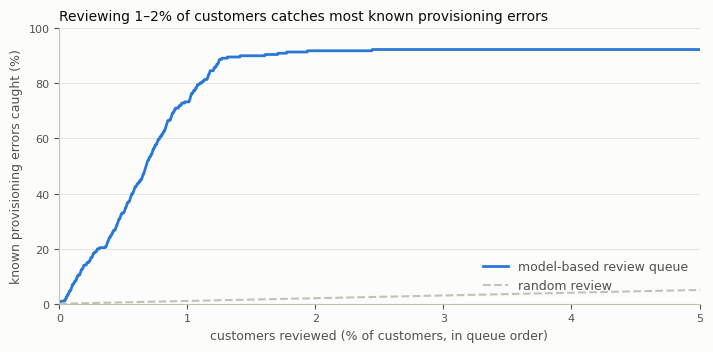

separately, 8.6% of validation customers have a CRM record that itself looks corrupted (impossible categories or bursts of rare products) -> a CRM data-quality queue


In [17]:
Y_obs = Y_raw[va][cl]                    # what the billing system actually contains
e = noisy[va][cl]                        # known provisioning errors
disagree = np.abs(P_val[cl] - Y_obs) > 0.5
flagged = disagree.any(1)
n_items = disagree.sum(1)
rare_cust = rare_tr[va][cl] > 0
key = (~flagged) * 1000 + rare_cust * 100 + n_items      # unflagged last; rare-product customers last; fewer items first
order = np.lexsort((np.arange(len(e)), key))
caught = np.cumsum(e[order]) / max(e.sum(), 1)
reviewed = np.arange(1, len(e) + 1) / len(e)
base = e.mean()
print(f'{len(e):,} customers with a clean-looking CRM record; known provisioning errors among them: '
      f'{e.sum()} ({base:.2%}); flagged by the rule: {flagged.mean():.1%}')
rows = []
for share in (0.005, 0.01, 0.02, flagged.mean()):
    k = int(share * len(e))
    hit = e[order[:k]].sum()
    rows.append({'review the top': f'{share:.1%} of customers', 'alerts per 10,000': round(share * 10_000),
                 'known errors caught': f'{hit / e.sum():.0%}', 'precision (lower bound)': f'{hit / k:.0%}',
                 'lift vs random review': f'{hit / k / base:.0f}x'})
display(pd.DataFrame(rows).set_index('review the top'))

fig, ax = plt.subplots(figsize=(7.2, 3.6))
ax.plot(reviewed * 100, caught * 100, color=BLUE, lw=2, label='model-based review queue')
ax.plot([0, 100], [0, 100], color=AXIS, lw=1.5, ls='--', label='random review')
ax.set_xlim(0, 5)
ax.set_ylim(0, 100)
style(ax, grid='y')
ax.set_xlabel('customers reviewed (% of customers, in queue order)', color=INK2)
ax.set_ylabel('known provisioning errors caught (%)', color=INK2)
ax.set_title('Reviewing 1–2% of customers catches most known provisioning errors', loc='left', color=INK, fontsize=10)
ax.legend(frameon=False, labelcolor=INK2, loc='lower right')
plt.tight_layout()
plt.show()

flag_corrupt = ~clean_like[va]
print(f'separately, {flag_corrupt.mean():.1%} of validation customers have a CRM record that itself looks corrupted '
      f'(impossible categories or bursts of rare products) -> a CRM data-quality queue')

On this split, reviewing the top 2% of customers catches 92% of the known errors, about 46
times better than reviewing customers at random.

### How reliable is the detector?

Two extra checks: a confidence interval on that recall, and **synthetic errors**. The known
errors are only small deviations in repeated configurations, so we also corrupt the bills of
clean customers ourselves (one to three missing or extra items) and see what the queue
catches.

In [18]:
n_cl = len(e)
codes_cl, _ = pd.factorize(groups[va][cl])


def ratio_ci(num, den, b=2000, seed=0):
    sn, sd = np.bincount(codes_cl, weights=num), np.bincount(codes_cl, weights=den)
    idx = np.random.default_rng(seed).integers(0, len(sn), size=(b, len(sn)))
    return np.percentile(sn[idx].sum(1) / np.maximum(sd[idx].sum(1), 1), [2.5, 97.5])


top2 = np.zeros(n_cl, bool)
top2[order[:int(0.02 * n_cl)]] = True
lo, hi = ratio_ci((e & top2).astype(float), e.astype(float))
print(f'1) known errors caught in the top 2%: {(e & top2).sum() / e.sum():.0%} '
      f'(95% CI {lo:.0%}-{hi:.0%}, resampling configurations)')


def queue_order(D):
    dis = D > 0.5
    k_ = (~dis.any(1)) * 1000 + rare_cust * 100 + dis.sum(1)
    return np.lexsort((np.arange(len(D)), k_))


rng_s = np.random.default_rng(1)
D0 = np.abs(P_val[cl] - Y_obs)
clean_idx = np.flatnonzero(~e)
item_prev = Y[keep].mean(0)
cfg_size = pd.Series(codes_cl).map(pd.Series(codes_cl).value_counts()).to_numpy()
unique_cfg = cfg_size == 1
syn = []
for kind in ('missing item', 'extra item'):
    for k in (1, 2, 3):
        res_ = []
        for _ in range(3):
            S = rng_s.choice(clean_idx, size=int(0.0065 * n_cl), replace=False)
            Ymod = Y_obs[S].copy()
            for r_ in range(len(S)):
                pool = np.flatnonzero(Ymod[r_] == (1 if kind == 'missing item' else 0))
                pick = (rng_s.choice(pool, size=min(k, len(pool)), replace=False) if kind == 'missing item'
                        else rng_s.choice(pool, size=k, replace=False, p=item_prev[pool] / item_prev[pool].sum()))
                Ymod[r_, pick] = 1 - Ymod[r_, pick]
            Dm = D0.copy()
            Dm[S] = np.abs(P_val[cl][S] - Ymod)
            in_top = np.zeros(n_cl, bool)
            in_top[queue_order(Dm)[:int(0.02 * n_cl)]] = True
            res_.append((in_top[S].mean(), in_top[S][unique_cfg[S]].mean(), in_top[S][~unique_cfg[S]].mean()))
        a = np.mean(res_, 0)
        syn.append({'injected error': kind, 'items': k, 'caught in top 2%': f'{a[0]:.0%}',
                    'unique configuration': f'{a[1]:.0%}', 'repeated configuration': f'{a[2]:.0%}'})
print(f'2) synthetic errors injected into {int(0.0065 * n_cl)} clean customers (3 repetitions each); '
      f'{unique_cfg[clean_idx].mean():.0%} of clean customers here have a unique configuration:')
display(pd.DataFrame(syn).set_index(['injected error', 'items']))

1) known errors caught in the top 2%: 92% (95% CI 86%-96%, resampling configurations)


2) synthetic errors injected into 216 clean customers (3 repetitions each); 26% of clean customers here have a unique configuration:


caught in top 2% unique configuration repeated configuration
injected error items                                                             
missing item   1                  94%                  81%                    99%
               2                  92%                  81%                    97%
               3                  94%                  80%                    98%
extra item     1                  92%                  77%                    98%
               2                  94%                  80%                    98%
               3                  91%                  76%                    97%

- **On the honest split (seed 7)**, the top 2% catches 83% of the known errors (95% CI 73–92%,
  from the project scripts); on this split it is 92%. Either way, about 40 times better than
  random review.
- **Synthetic errors** are caught about 92% of the time within a 2% review budget, whether one,
  two or three items are wrong. The weak spot is customers with a unique configuration, which
  is every test customer: there about 80% are caught.

**In production** this would run as a nightly batch with two queues: the billing check above,
whose size is set by the review budget, and a CRM data-quality queue for records with
impossible categories or bursts of rare products. Thresholds are recomputed from the live CRM
base, the model is retrained monthly or when new products launch, and alert volume and the
confirmed-error rate are monitored.

<a id="shap"></a>
# 9. Explainability: what did the model learn?

We use SHAP values (LightGBM's built-in TreeSHAP) on clean-like validation customers. For each
billing item we ask which CRM product drives it, and compare the answer with an **expected
driver** computed without the model: the CRM product that co-occurs most with the item in the
training data. Agreement between the two is therefore a real check.

In [19]:
Xf, Yf = Xu.astype(np.float32), Yu.astype(np.float32)
inter = Xf.T @ Yf
cooc = np.minimum(inter / np.maximum(Xf.sum(0)[:, None], 1), inter / np.maximum(Yf.sum(0)[None, :], 1))
expected, expected_score = cooc.argmax(0), cooc.max(0)

rng = np.random.default_rng(0)
Xv = X[va].astype(np.float32)
cl_idx = np.flatnonzero(cl)
imp = np.zeros((len(bil_cols), len(crm_cols)), np.float32)
pos_rows = {}
t0 = time.time()
for j, m in enumerate(models):
    rows = cl_idx[(Yv[cl_idx, j] == 1) | (pred_val[cl_idx, j] == 1)]
    if len(rows) > 400:
        rows = rng.choice(rows, 400, replace=False)
    if len(rows) == 0:
        rows = rng.choice(cl_idx, 400, replace=False)
    pos_rows[j] = Xv[rows]
    if not isinstance(m, float):
        imp[j] = np.abs(m.booster_.predict(pos_rows[j], pred_contrib=True)[:, :-1]).mean(0)
print(f'SHAP for 731 models in {time.time() - t0:.0f}s')

top = imp.argmax(1)
conc = imp.max(1) / np.maximum(imp.sum(1), 1e-12)
tp_, fp_, fn_ = (((yt == 1) & (yp == 1)).sum(0), ((yt == 0) & (yp == 1)).sum(0), ((yt == 1) & (yp == 0)).sum(0))
f1_col = np.where(tp_ + fp_ + fn_ > 0, 2 * tp_ / np.maximum(2 * tp_ + fp_ + fn_, 1), np.nan)
in_top3 = np.array([expected[j] in np.argsort(-imp[j])[:3] for j in range(len(bil_cols))])
strong = expected_score >= 0.8
display(pd.DataFrame([
    {'BIL columns': 'with a clear expected driver (score >= 0.8)', 'count': strong.sum(),
     'top SHAP driver = expected': (top == expected)[strong].mean(), 'expected in SHAP top 3': in_top3[strong].mean()},
    {'BIL columns': 'without one', 'count': (~strong).sum(),
     'top SHAP driver = expected': (top == expected)[~strong].mean(), 'expected in SHAP top 3': in_top3[~strong].mean()},
]).set_index('BIL columns').style.format({'top SHAP driver = expected': '{:.1%}', 'expected in SHAP top 3': '{:.1%}'}))

SHAP for 731 models in 20s


,count,top SHAP driver = expected,expected in SHAP top 3
BIL columns,,,
with a clear expected driver (score >= 0.8),233,95.7%,99.1%
without one,498,46.4%,50.2%


Where a clear product-to-billing link exists (233 items), the model's main driver is the
expected one 96% of the time, and it is in the top three 99% of the time. The other 498 items
have no single dominant cause, so this check does not apply to them.

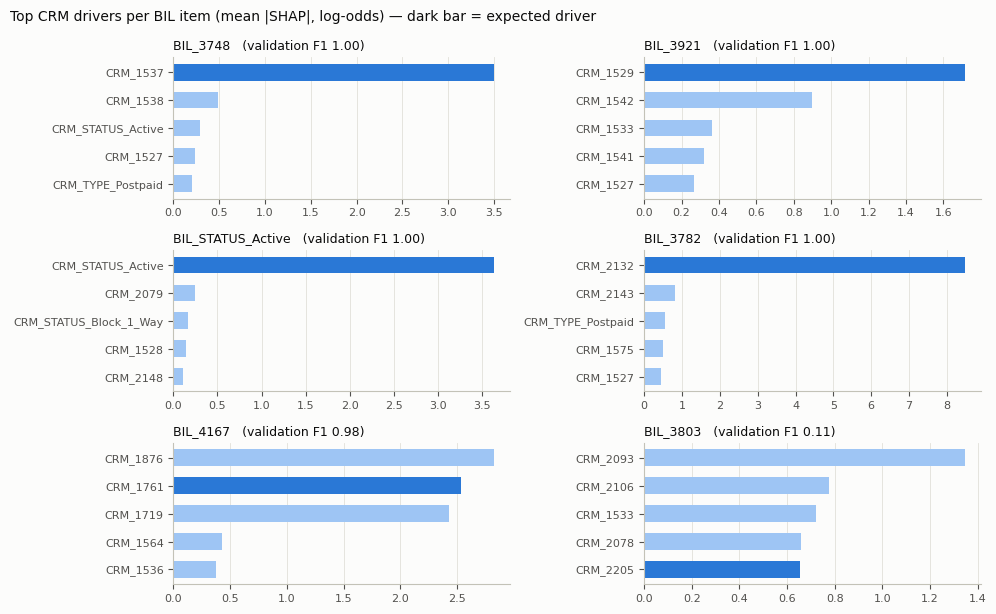

In [20]:
SELECTED = ['BIL_3748_PACK', 'BIL_3921_PACK', 'BIL_SUBSCRIBER_STATUS_ORIG_Active', 'BIL_3782_PACK',
            'BIL_4167_PACK', 'BIL_3803_PACK']
short = lambda c: c.replace('_PACK', '').replace('SUBSCRIBER_STATUS_ORIG_', 'STATUS_').replace('SUBSCRIBER_TYPE_ORIG_', 'TYPE_')
crm_arr = np.array(crm_cols)
fig, axes = plt.subplots(3, 2, figsize=(10, 6.2))
for ax, b in zip(axes.ravel(), SELECTED):
    j = bil_cols.index(b)
    order = np.argsort(-imp[j])[:5][::-1]
    ax.barh([short(crm_arr[f]) for f in order], imp[j, order],
            color=[BLUE if f == expected[j] else LIGHT_BLUE for f in order], height=0.6)
    style(ax)
    ax.set_title(f'{short(b)}   (validation F1 {f1_col[j]:.2f})', loc='left', color=INK, fontsize=9)
fig.suptitle('Top CRM drivers per BIL item (mean |SHAP|, log-odds) — dark bar = expected driver',
             x=0.01, ha='left', color=INK, fontsize=10)
plt.tight_layout()
plt.show()

Some examples from the chart: `BIL_3748` is driven by `CRM_1537`, the billing `Active` status
by the CRM `Active` status, and the rare `BIL_3782` by the rare `CRM_2132`. `BIL_4167` is billed
for any of three CRM products, which is the many-to-one mapping described in the brief, and the
model handles it. `BIL_3803` has no dominant cause, and its F1 is low.

### Where the errors come from

,columns,median_F1
band,,
≤ 0.3 (diffuse),299,0.00
0.3–0.5,116,0.67
0.5–0.7,148,0.95
> 0.7 (one clear driver),168,0.99


Spearman(concentration, F1) over 726 columns: +0.86


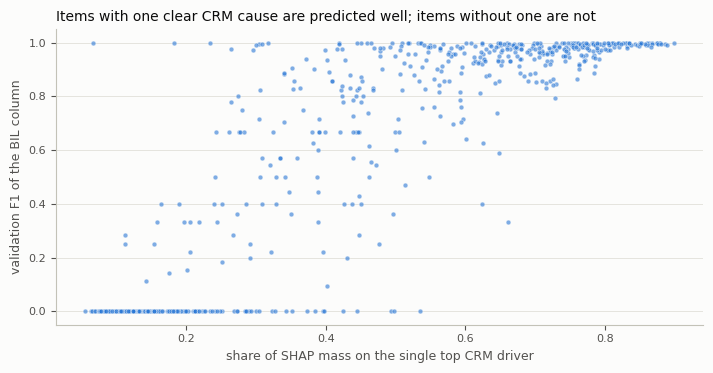

noise check: median SHAP share on rare CRM packs 1.1%; 119 columns lean > 50% on rare packs, and for 100% of them that rare pack is the column's own expected driver


In [21]:
ok = ~np.isnan(f1_col)
bands = pd.cut(conc, [0, 0.3, 0.5, 0.7, 1.0], labels=['≤ 0.3 (diffuse)', '0.3–0.5', '0.5–0.7', '> 0.7 (one clear driver)'])
summary = pd.DataFrame({'band': bands, 'f1': f1_col}).groupby('band', observed=True).agg(
    columns=('f1', 'size'), median_F1=('f1', 'median'))
display(summary.style.format({'median_F1': '{:.2f}'}))
print(f'Spearman(concentration, F1) over {ok.sum()} columns: {spearmanr(conc[ok], f1_col[ok]).statistic:+.2f}')

fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.scatter(conc[ok], f1_col[ok], s=12, color=BLUE, alpha=0.6, edgecolors=SURFACE, linewidths=0.5)
style(ax, grid='y')
ax.set_xlabel('share of SHAP mass on the single top CRM driver', color=INK2)
ax.set_ylabel('validation F1 of the BIL column', color=INK2)
ax.set_title('Items with one clear CRM cause are predicted well; items without one are not',
             loc='left', color=INK, fontsize=10)
plt.tight_layout()
plt.show()

share_rare = imp[:, rare_crm].sum(1) / np.maximum(imp.sum(1), 1e-12)
hi = share_rare > 0.5
print(f'noise check: median SHAP share on rare CRM packs {np.median(share_rare):.1%}; '
      f'{hi.sum()} columns lean > 50% on rare packs, and for {np.mean(rare_crm[expected[hi]]):.0%} of them '
      f'that rare pack is the column\'s own expected driver')

- **Items with one clear cause are predicted well; diffuse items are not.** How concentrated an
  item's explanation is predicts its F1 (rank correlation +0.86).
- **The model does not learn the injected noise.** When an item leans on a rare product, it is
  always that item's own expected product, never an unrelated one.

### One error, explained

In [22]:
err_rows = np.flatnonzero(cl & ((pred_val != Yv).sum(1) == 1))
cands = [(i, int(np.flatnonzero(pred_val[i] != Yv[i])[0])) for i in err_rows]
# Prefer a missed item whose expected driver (a rare product) is present; else any missed item.
example = next(((i, j) for i, j in cands if Yv[i, j] == 1 and Xv[i, expected[j]] == 1 and rare_crm[expected[j]]),
               next((i, j) for i, j in cands if Yv[i, j] == 1))
i, j = example
contrib = models[j].booster_.predict(Xv[i:i + 1], pred_contrib=True)[0]
present = np.flatnonzero(Xv[i] == 1)
order = present[np.argsort(-np.abs(contrib[present]))][:5]
print(f'{bil_cols[j]} is billed for this customer, but the model predicted p = {P_val[i, j]:.2f} (< 0.5)')
print(f'baseline log-odds {contrib[-1]:+.2f}; largest contributions from the CRM columns the customer has:')
for f in order:
    print(f'   {crm_cols[f]:34s} {contrib[f]:+6.2f}' + ('   <- expected driver (rare product)' if f == expected[j] else ''))

BIL_4139_PACK is billed for this customer, but the model predicted p = 0.23 (< 0.5)
baseline log-odds -8.44; largest contributions from the CRM columns the customer has:
   CRM_1727_PACK                       +7.60   <- expected driver (rare product)
   CRM_1570_PACK                       +0.63
   CRM_1608_PACK                       +0.55
   CRM_1525_PACK                       -0.50
   CRM_1606_PACK                       -0.46


The model found the right cause: the rare CRM product pushes strongly towards billing the item.
With only a handful of clean training examples, though, the evidence stops short of the 0.5
threshold. This is the typical remaining error, and it is what Stage 2 targets.

<a id="submission"></a>
# 10. Final training and submission

The frozen model is re-fitted on all of `train.csv` (minus the suspected-corrupted rows) and
applied to the test set. The list of long-tail items for Stage 2 is rebuilt from the training
data alone.

In [23]:
keep_all = test_like & (rare_tr < 4)
Xa, Ya = unique_configs(X[keep_all], Y[keep_all])
t0 = time.time()
final_models = fit_models(Xa, Ya)
_, pred_test1 = predict(final_models, X_test)
print(f'Stage 1: dropped {(~keep_all).sum():,} rows ({(~keep_all).mean():.1%}); trained on {len(Xa):,} unique '
      f'configurations in {time.time() - t0:.0f}s')

t0 = time.time()
lt_all = long_tail_labels(Ya, oof_proba(Xa, Ya), config_weights(X[keep_all]))
final_spec = fit_specialists(Xa, Ya, lt_all)
pred_test = two_stage(pred_test1, final_spec, lt_all, X_test)
added = pred_test != pred_test1
print(f'Stage 2: {len(lt_all)} long-tail items (training OOF F1 < 0.5); {int(added.sum())} billing items added '
      f'for {int(added.any(1).sum())} test customers [{time.time() - t0:.0f}s]')

sub = pd.DataFrame({'MSISDN': msisdn_test, 'Bill_Conf': [''.join(r) for r in pred_test.astype(str)]})
assert len(sub) == 97_100 and sub.notna().all().all() and sub['MSISDN'].is_unique
assert sub['Bill_Conf'].str.len().eq(731).all() and sub['Bill_Conf'].str.fullmatch('[01]+').all()
os.makedirs(OUT, exist_ok=True)
sub.to_csv(f'{OUT}/submission_sprint3_final.csv', index=False)
print('written data/derived/submission_sprint3_final.csv:', sub.shape)
sub.head(3)

Stage 1: dropped 13,131 rows (7.0%); trained on 54,387 unique configurations in 386s


Stage 2: 332 long-tail items (training OOF F1 < 0.5); 787 billing items added for 655 test customers [1510s]


written data/derived/submission_sprint3_final.csv: (97100, 2)


,MSISDN,Bill_Conf
0,db67b03cf9fb8ea96077cd34c7a28139,10000000000000000000000000000000000000000000000000000000000000000000000101100001010001...
1,2ac0d310d5cf1a96587af614d37b8b54,10000000001000000000000000000001000000000000000000000000000000000000000001100011000001...
2,a8f289fbd263794ac74059a18c1d10a5,11000001101111000000000000000000000100000000000000000000000000000000000000000000000000...


Stage 2 adds 787 billing items for 655 of the 97,100 test customers. Everything else comes
from Stage 1.

<a id="test"></a>
# 11. Test results

The model is now frozen. Only at this point is `solution.csv` read, to score the submission. It
was never used for training or for any modelling choice.

In [24]:
sol = pd.read_csv(f'{DATA}/solution.csv', dtype=str)
m = sub.merge(sol, on='MSISDN', suffixes=('', '_true'))
assert len(m) == len(sub) == len(sol) and (m['MSISDN'].to_numpy() == msisdn_test).all()
to_bits = lambda s: np.array([np.frombuffer(x.encode(), np.uint8) - 48 for x in s])
Yt_test, Yp_test = to_bits(m['Bill_Conf_true']), to_bits(m['Bill_Conf'])
wrong = (Yt_test != Yp_test).sum(1)
test_emr = np.mean(wrong == 0)
display(pd.Series({
    'test EMR': f'{test_emr:.2%}',
    'rows exactly right': f'{(wrong == 0).sum():,} of {len(wrong):,}',
    'rows 1 bit off': f'{np.mean(wrong == 1):.2%}',
    'rows 2+ bits off': f'{np.mean(wrong >= 2):.2%}',
    'bit accuracy': f'{(Yt_test == Yp_test).mean():.5%}',
    'F1 micro': f'{f1_score(Yt_test, Yp_test, average="micro"):.4f}',
}).to_frame('test (solution.csv)'))

# Every test row is its own CRM configuration, so a plain binomial interval is appropriate here.
print(f'distinct CRM configurations in test: {factorize_rows(X_test)[1]:,} of {len(X_test):,} rows')
half = 1.96 * np.sqrt(test_emr * (1 - test_emr) / len(wrong))
print(f'95% confidence interval: [{test_emr - half:.2%}, {test_emr + half:.2%}] (±{half * 100:.2f} pt)')
test_emr1 = np.mean((pred_test1 == Yt_test).all(1))
print(f'Stage 1 alone: test EMR {test_emr1:.2%} -> Stage 2 adds {(test_emr - test_emr1) * 100:+.2f} pt '
      f'({(test_emr - test_emr1) * len(wrong):+.0f} customers)')
act_t = Yt_test.sum(0) > 0
f1m = lambda Pr: f1_score(Yt_test[:, act_t], Pr[:, act_t], average='macro', zero_division=0)
print(f'test macro F1 (items with a positive): Stage 1 {f1m(pred_test1):.4f} -> final {f1m(Yp_test):.4f}')
be = (Yt_test != Yp_test).mean()
print(f'bit error rate {be:.2e}: EMR if errors were independent {(1 - be) ** 731:.2%} vs actual {test_emr:.2%}')

,test (solution.csv)
test EMR,97.51%
rows exactly right,"94,681 of 97,100"
rows 1 bit off,1.91%
rows 2+ bits off,0.58%
bit accuracy,99.99465%
F1 micro,0.9987


distinct CRM configurations in test: 97,100 of 97,100 rows
95% confidence interval: [97.41%, 97.61%] (±0.10 pt)
Stage 1 alone: test EMR 97.21% -> Stage 2 adds +0.30 pt (+290 customers)


test macro F1 (items with a positive): Stage 1 0.7013 -> final 0.7693
bit error rate 5.35e-05: EMR if errors were independent 96.17% vs actual 97.51%


- **Final test EMR: 97.51%** (95% CI 97.41–97.61), against 97.21% for Stage 1 alone. Stage 2
  adds 290 customers who are exactly right.
- Test macro F1 rises from 0.70 to 0.77.
- 1.9% of customers are off by a single item, and 0.6% by two or more.

### Was removing the corrupted rows worth it?

We train Stage 1 on all of `train.csv`, without removing the suspected-corrupted rows, and
compare it with Stage 1 trained with the filter. Stage 2 is left out on both sides, so only the
filter differs.

Stage 1 without the filter: test EMR 94.67% | with the filter: 97.21% | difference +2.54 pt (+2467 customers) [248s]


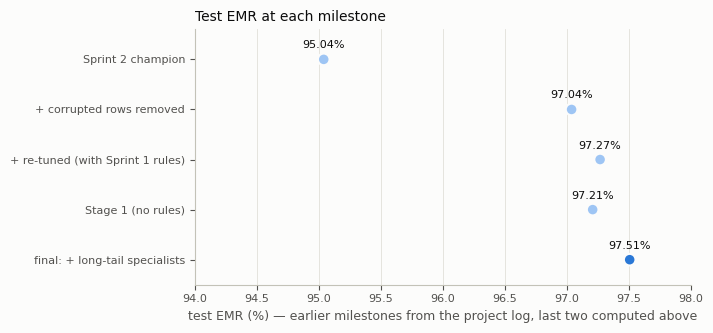

In [25]:
Xn, Yn = unique_configs(X, Y)
t0 = time.time()
_, pred_nofilter = predict(fit_models(Xn, Yn), X_test)
truth = sol.set_index('MSISDN').loc[msisdn_test, 'Bill_Conf'].to_numpy()
emr_nofilter = np.mean(np.array([''.join(r) for r in pred_nofilter.astype(str)]) == truth)
print(f'Stage 1 without the filter: test EMR {emr_nofilter:.2%} | with the filter: {test_emr1:.2%} | '
      f'difference {(test_emr1 - emr_nofilter) * 100:+.2f} pt ({(test_emr1 - emr_nofilter) * len(wrong):+.0f} customers) '
      f'[{time.time() - t0:.0f}s]')

milestones = {'Sprint 2 champion': 0.9504, '+ corrupted rows removed': 0.9704,
              '+ re-tuned (with Sprint 1 rules)': 0.9727, 'Stage 1 (no rules)': test_emr1,
              'final: + long-tail specialists': test_emr}
labels = list(milestones)[::-1]
vals = [milestones[k] * 100 for k in labels]
fig, ax = plt.subplots(figsize=(7.2, 3.4))
# Dots, not bars: the axis is zoomed to 94-99%, and bars would exaggerate the differences.
ax.scatter(vals, labels, s=70, color=[BLUE] + [LIGHT_BLUE] * 4, edgecolors=SURFACE, linewidths=1.5, zorder=3)
for y, v in enumerate(vals):
    ax.text(v, y + 0.22, f'{v:.2f}%', ha='center', color=INK, fontsize=8)
ax.set_xlim(94, 98)
ax.set_ylim(-0.5, 4.6)
style(ax)
ax.set_xlabel('test EMR (%) — earlier milestones from the project log, last two computed above', color=INK2)
ax.set_title('Test EMR at each milestone', loc='left', color=INK, fontsize=10)
plt.tight_layout()
plt.show()

Without the filter, test EMR is 94.67%. Removing the suspected-corrupted rows is worth **+2.5
points**, about 2,500 customers: the largest single improvement in the project. The chart sums
up the path from Sprint 2 to the final model.

<a id="conclusions"></a>
# 12. Conclusions

1. **Generalise, don't memorise.** Test customers are new, so validation keeps identical
   customers together and scores against consensus bills.
2. **One model per billing item works, because billing is close to additive per product.** Even
   a tuned linear model comes within 0.2 points. Sprint 1's SVD and column collapsing hurt.
3. **The biggest gain came from the data, not the model.** About 7% of training rows look
   corrupted by random injection. Removing them and re-tuning took test EMR from 95.0% to 97.2%.
4. **Part of the long tail can be recovered.** Specialists for rare billing items, allowed only
   to add items for customers with rare products, raise both EMR and macro F1 on every split and
   fold, and lift test EMR to **97.51%**.
5. **The model is useful in practice.** Reviewing 2% of customers catches over 80% of known
   provisioning errors, about 40 times better than random review.
6. **The model learned the real product mapping.** SHAP shows it relies on the expected CRM
   product and ignores the injected noise.
7. **What is left.** The remaining errors, about 2.5% of test customers, are mostly customers
   with rare products: billing items that look like injected noise, and real product links with too few
   training examples.

<a id="appendix-a"></a>
# Appendix A. Full experiment results

These results come from the project's experiment scripts (`scripts/`) and are reported, not
recomputed. Validation EMR is on clean-like rows unless stated otherwise.

**Sprint 2: model families** (validation EMR on all rows, seed 42)

| Model | Validation EMR |
|---|---|
| Hamming k-NN (k = 15): copy the bill of similar customers | 51.98% |
| Label powerset: choose among billing configurations seen in training | 23.09% |
| One LightGBM per item, Sprint 1 Section 10 pipeline as built | 50.58% |
| One LightGBM per item, Sprint 1 Section 11 pipeline (45 SVD components) as built | 12.80% |
| One LightGBM per item, raw CRM, unique configurations weighted by multiplicity | 58.66% |
| One LightGBM per item, raw CRM, unique configurations, unweighted | 80.05% |
| Classifier chain (co-occurrence order) | 80.57% |
| **One LightGBM per item, regularised (Sprint 2 model)** | **87.84%** |

**Sprint 2: feature sets** (same training rows and labels)

| Features | Validation EMR |
|---|---|
| Raw 745 CRM columns | 80.05% |
| Section 10 features (correlated columns collapsed) | 74.31% |
| Section 11 features (+45 SVD components) | 47.42% |

**Sprint 3: how many rare products make a row "corrupted"?** (drop rows with at least k rare
products, or not test-like)

| k | Training rows dropped | Seed 42 | Seed 7 |
|---|---|---|---|
| no drop (Sprint 2 model) | 0% | 95.93% | 95.06% |
| 2 | 9.8% | 95.45% | — |
| 3 | 8.1% | 96.41% | — |
| **4 (selected)** | **6.9%** | **96.57%** | **96.15%** |
| 5 | 5.8% | 96.50% | — |
| 6 | 4.9% | 96.62% | 95.80% |
| 8 | 3.4% | 96.30% | — |

**Sprint 3: re-tuning on the clean data**

| Setting | Seed 42 | Seed 7 |
|---|---|---|
| `min_child_samples` 20 | 96.57% | 96.15% |
| `min_child_samples` 10 | 96.78% | 96.11% |
| **`min_child_samples` 5 (selected)** | **96.81%** | **96.33%** |
| `min_child_samples` 2 | 96.82% | 96.36% |
| `min_child_samples` 5, `reg_lambda` 5 | 96.61% | 96.25% |
| `min_child_samples` 5, `reg_lambda` 0 | 33.00% | 26.29% |
| + confident-learning cleaning | 96.59% | 96.01% |
| + repair corrupted rows instead of dropping them | 96.60% | 96.03% |
| + more capacity (200 trees, 31 leaves) | 96.87% | 96.39% |
| + basket-size count features | 96.79% | 96.41% |

These figures include the 42 Sprint 1 additive rules, which were later dropped: they were mined
on all of `train.csv` and added only about six customers. Without them the Stage 1 model scores
96.79% and 96.30%.

**Baselines on the same footing**

| Model | Seed 42 | Seed 7 |
|---|---|---|
| Hamming k-NN (k = 15) | 56.81% | 49.64% |
| Rules floor: bill an item if a CRM product implies it at least 90% of the time | 67.94% | 74.15% |
| Logistic regression per item, untuned (C = 1) | 95.97% | 94.61% |
| Logistic regression per item, tuned (C = 10) | 96.56% | 96.15% |
| **LightGBM per item (Stage 1)** | **96.79%** | **96.30%** |

**Paired tests for the key decisions** (difference in points, with a 95% interval from
resampling configurations)

| Decision | Seed 42 | Seed 7 | Verdict |
|---|---|---|---|
| Drop suspected-corrupted rows (k = 4) | +0.81 [+0.44, +1.19] | +1.25 [+0.91, +1.74] | adopted |
| `min_child_samples` 5 instead of 20 | +0.27 [+0.08, +0.62] | +0.20 [+0.08, +0.35] | adopted |
| Sprint 1 additive rules | +0.02 [+0.00, +0.04] | +0.02 [+0.00, +0.05] | dropped: tiny, and mined on all of train |
| Lower threshold (0.45) for rare items | +0.07 [+0.02, +0.16] | +0.10 [+0.03, +0.23] | not adopted: +0.03 in 5-fold, below the 0.1-point bar set before testing |
| More capacity | +0.04 [−0.04, +0.15] | +0.05 [−0.12, +0.23] | not significant |
| `min_child_samples` 2 instead of 5 | −0.00 [−0.05, +0.04] | +0.03 [−0.03, +0.08] | not significant |
| Basket-size count feature | −0.02 [−0.08, +0.03] | +0.09 [−0.00, +0.23] | inconsistent |
| LightGBM instead of tuned logistic regression | +0.23 [+0.14, +0.34] | +0.16 [−0.04, +0.33] | LightGBM kept |
| Stage 2 specialists (EMR) | +0.12 [+0.07, +0.18] | +0.19 [+0.08, +0.34] | adopted (positive in all 5 folds) |

**Stage 2: approaches tried for the long-tail items** (paired against Stage 1, both splits)

| Approach | Result | Verdict |
|---|---|---|
| Per-item thresholds tuned on training out-of-fold predictions | macro F1 +0.01, but EMR −0.1 to −0.9 points; the EMR-safe version gains only +0.001–0.002 | rejected |
| Specialists fed with all Stage-1 probabilities, or with co-occurrence community activations | they latch onto the stacked probabilities; EMR −0.4 to −26 points | rejected |
| Specialists + probabilities of related common items (targeted classifier chain) | weaker than CRM alone; EMR not significant on seed 7 | rejected |
| Specialists + mined CRM-pattern indicators | ties with CRM alone in a paired test | rejected (simpler wins) |
| Deterministic CRM-pattern override (training precision at least 0.9) | 3–4 customers | rejected (negligible) |
| **Specialists on CRM, class-weighted, add-only, only for customers with a rare product** | **macro F1 +0.014 / +0.015, EMR +0.12 / +0.19 points, positive in all 5 folds** | **adopted** |

**5-fold cross-validation of Stage 2** (GroupKFold by configuration; everything rebuilt in each
fold)

| Model | Clean-like EMR | Macro F1 | Customers fixed / broken (all folds) |
|---|---|---|---|
| Stage 1 | 96.83% ± 0.20 | 0.524 ± 0.005 | — |
| **Stage 1 + Stage 2** | **96.99% ± 0.20** | **0.539 ± 0.005** | 346 / 82 |
| Simpler alternative: threshold 0.3 on long-tail items, same condition | 96.93% ± 0.19 | 0.532 ± 0.005 | 181 / 17 |

**Test EMR at each milestone** (computed after each model was frozen)

| Milestone | Test EMR |
|---|---|
| Sprint 2 model | 95.04% |
| Suspected-corrupted rows removed | 97.04% |
| Re-tuned on clean data (with Sprint 1 rules) | 97.27% |
| Stage 1, professor's files only, no Sprint 1 rules | 97.21% |
| **Stage 1 + Stage 2 (final)** | **97.51%** |

<a id="appendix-b"></a>
# Appendix B. Threats to validity

| Risk | How it is handled |
|---|---|
| The Sprint 1 additive rules were mined on all of `train.csv`, including later validation rows. | Removed from the final model; their gain was about six customers. |
| Sprint 1 SVD and feature selection were fitted on all of `train.csv`. | Not used by the final model, which uses the raw columns. |
| The clean-like metric and the corruption filter were designed by comparing training and test *inputs*. | Inputs only, never test labels; disclosed here. Key decisions are also checked with paired tests, 5-fold cross-validation and on test. |
| Validation customers with the same configuration are not independent. | Uncertainty is computed by resampling configurations; decisions use paired tests. |
| Does the grouped split mirror the test set? | Only partly: validation customers are closer to a training customer than test customers are, but validation keeps more unusual customers. The two biases partly cancel, so validation is used to rank choices and the test set to measure the result. |
| Removing rows could bias the evaluation. | Rows are removed from training only; the test score uses all 97,100 test customers. |
| `solution.csv` was scored at several milestones. | Always after the model was frozen, never to choose anything. It is a diagnostic, not an untouched holdout. |
| The Stage 2 rare-product condition was chosen after seeing errors on the seed-42 split. | Confirmed on seed 7 and in all five folds; it uses CRM inputs only. |
| Stage 2 was selected among several variants. | All variants were compared on the same baseline with paired tests on two splits; the chosen one is the simplest that won, and it held in 5-fold. |
| Earlier experiments are reported, not recomputed. | They come from the project scripts and leaderboard; the final model and the filter ablation run live here. |
| Error-detection precision. | Measured only on provisioning errors that can be confirmed, so it is a lower bound. |

<a id="appendix-c"></a>
# Appendix C. Glossary

| Term | Meaning |
|---|---|
| EMR (exact match ratio) | Share of customers whose 731 predicted billing items are *all* correct |
| CRM configuration | A customer's full 745-flag CRM record; identical records form one configuration |
| Consensus target | For a CRM configuration seen several times, its most frequent complete bill |
| Test-like row | A row whose one-hot blocks are valid: exactly one status, type and business line, never the value `0` |
| Rare product (rare pack) | A CRM product held by fewer than 0.2% of training customers |
| Clean-like row | A test-like row with fewer than three rare products; the validation population that behaves like the test set |
| Suspected-corrupted row | A training row that is not test-like or has four or more rare products; removed before training |
| Long-tail item | A billing item whose out-of-fold F1 inside the training data is below 0.5 (about 330 items) |
| Stage 1 / Stage 2 | Stage 1 is one LightGBM per billing item. Stage 2 adds class-weighted specialists for long-tail items, which may only add items for customers with a rare product |
| Paired test | Both models scored on the same resampled customers, so shared noise cancels out |